# 🏋️‍♂️ModelFitness Churn Prediction

## 1. Data Loading and Environment Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, precision_score, recall_score 

In [2]:
df = pd.read_csv('datasets/gym_churn_us.csv')

## 2. Exploratory Data Analysis (EDA)

In [3]:
# Análisis inicial
print(df.info())
print()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
# Correcting column names
columns_names = df.columns
new_columns_names = []
for name in columns_names.to_list():
    new_columns_names.append(name.lower().strip())

df.columns = new_columns_names 
df.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='str')

In [5]:
# check for missing values
print(df.describe())

# check for the mean values of the features
print('\nmean values of features from churned users (1) and active users (0)')
df.groupby('churn').mean()

            gender  near_location      partner  promo_friends        phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       contract_period  group_visits          age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


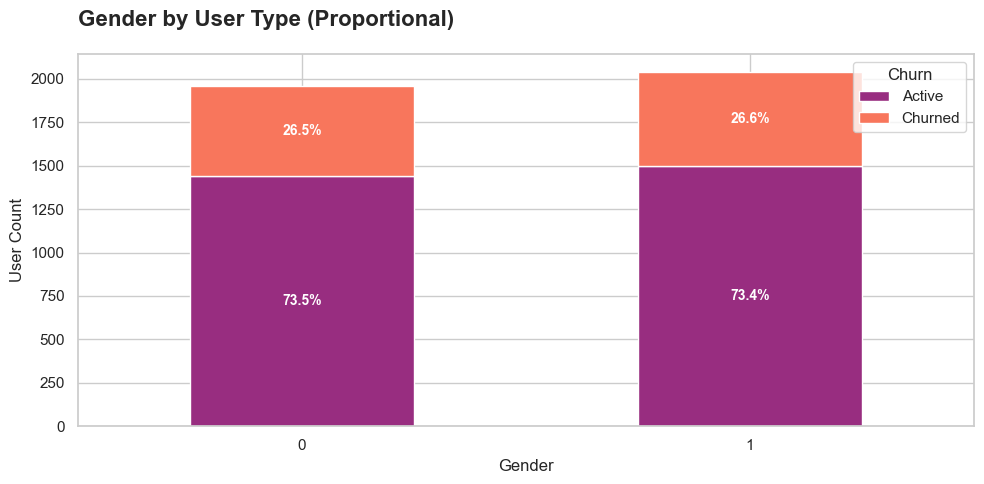

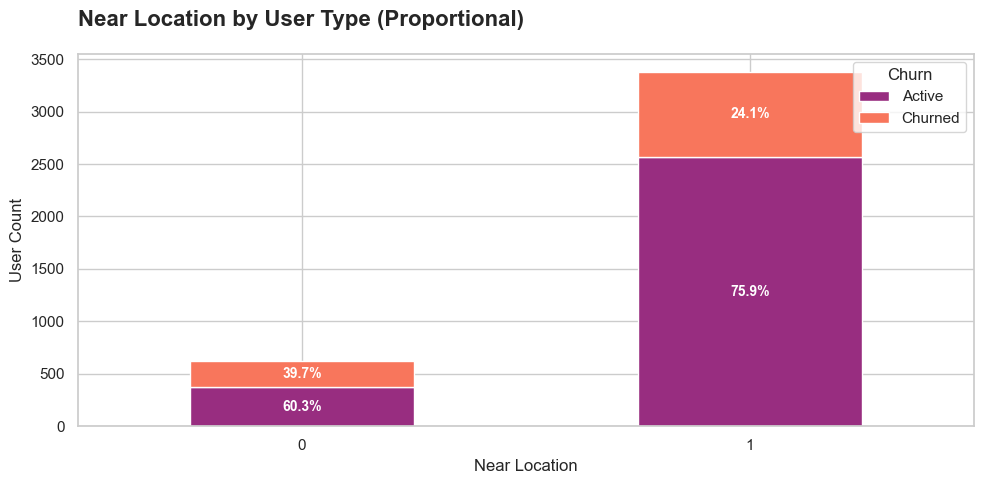

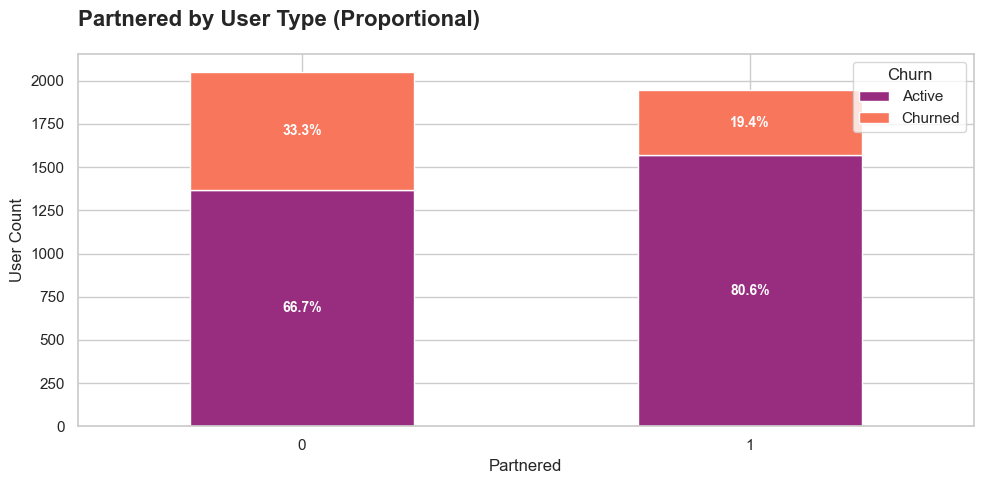

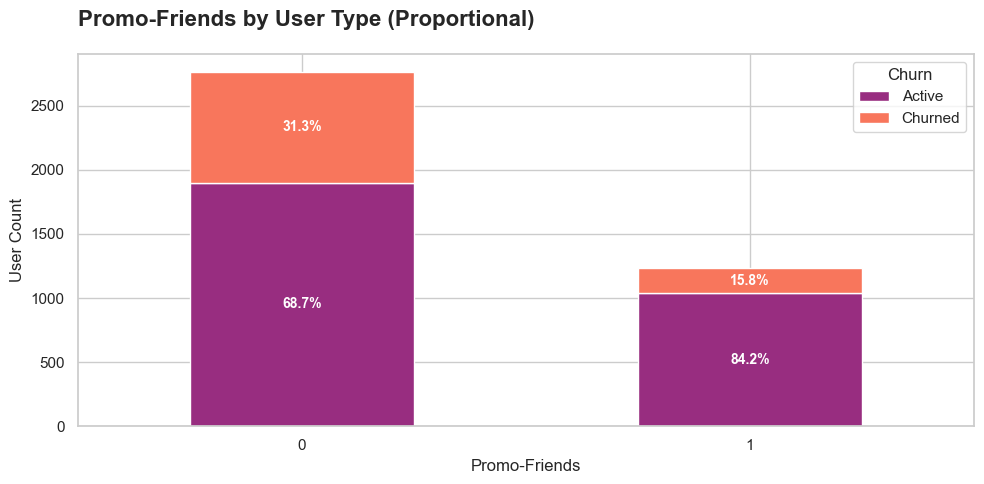

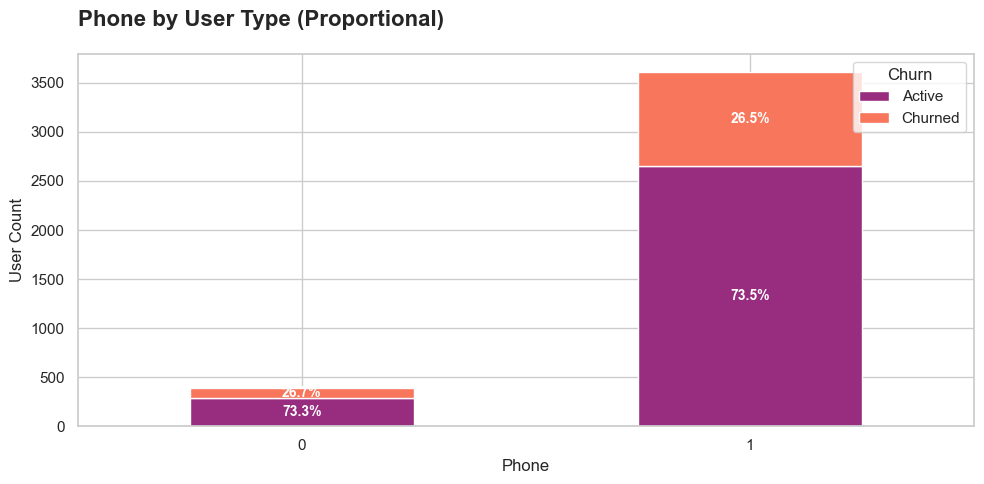

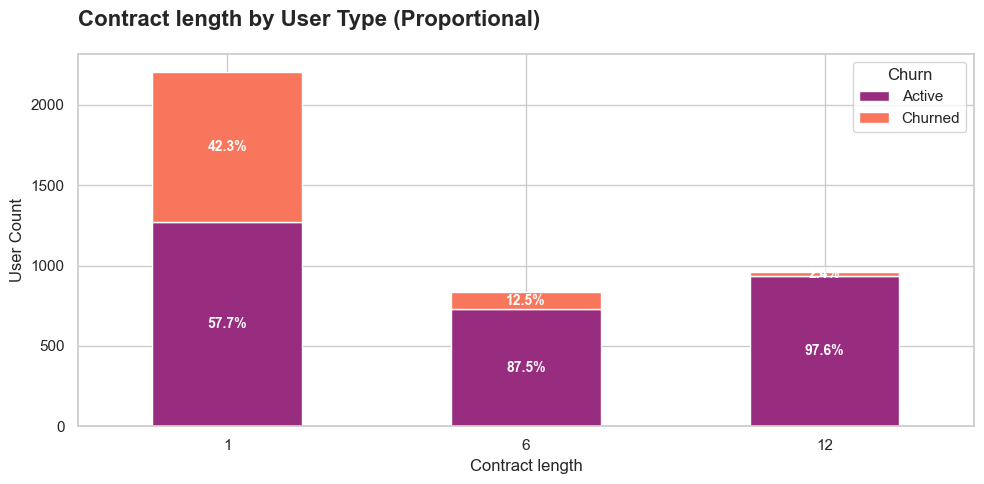

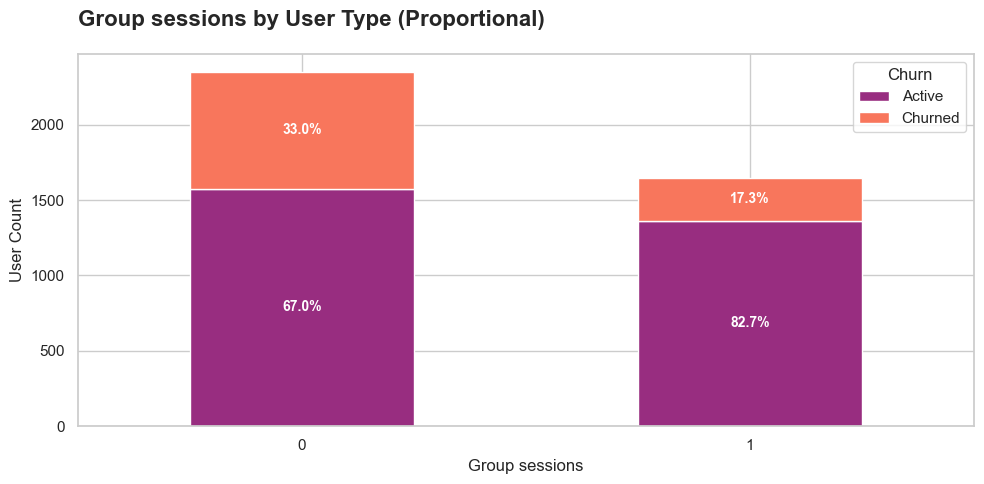

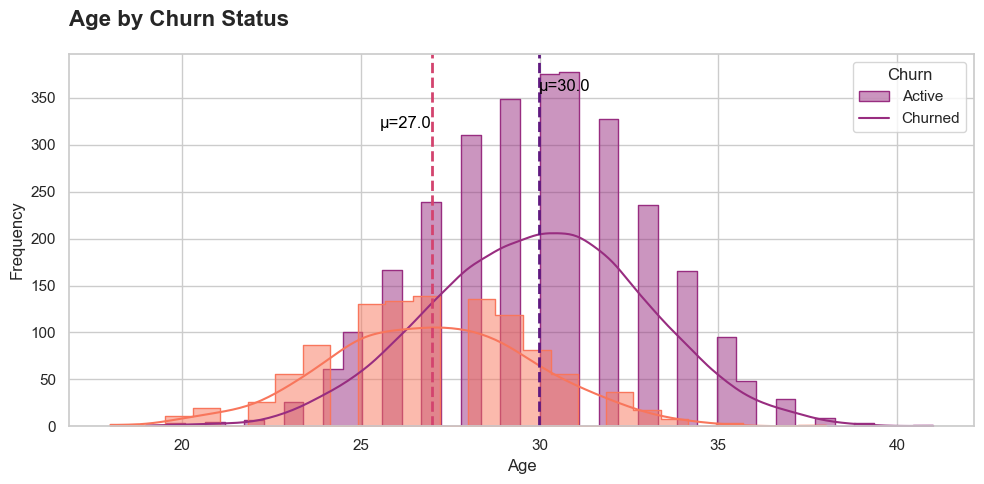

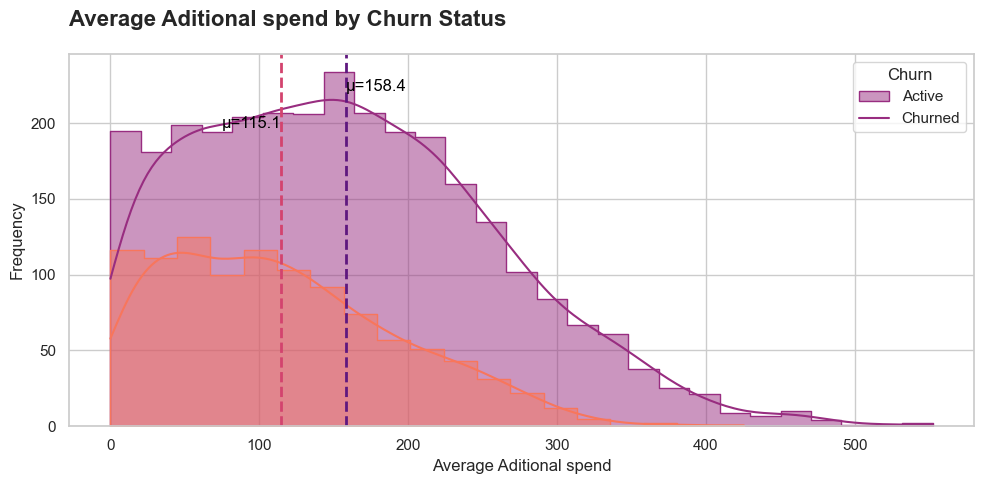

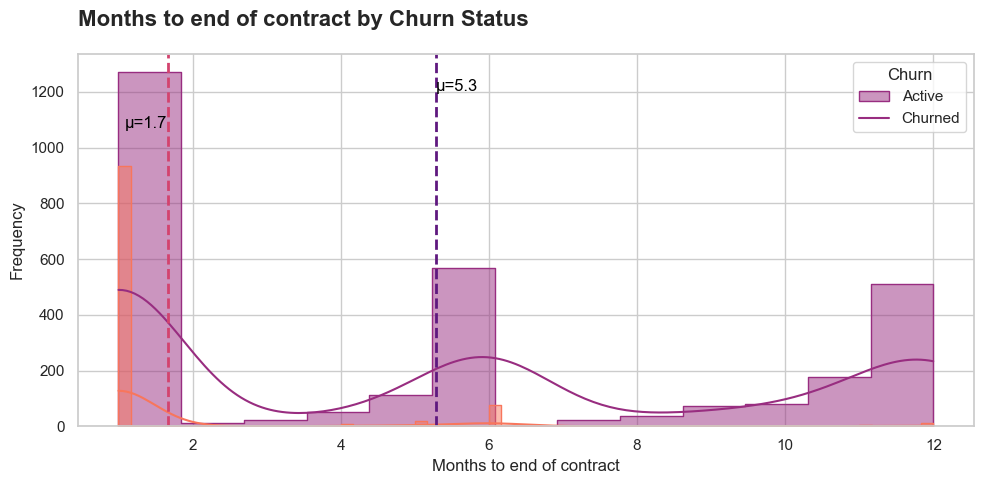

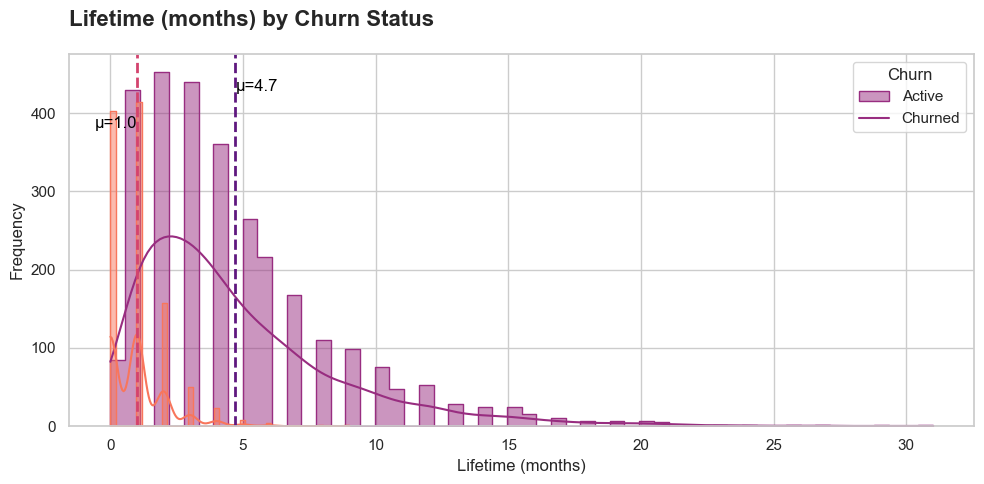

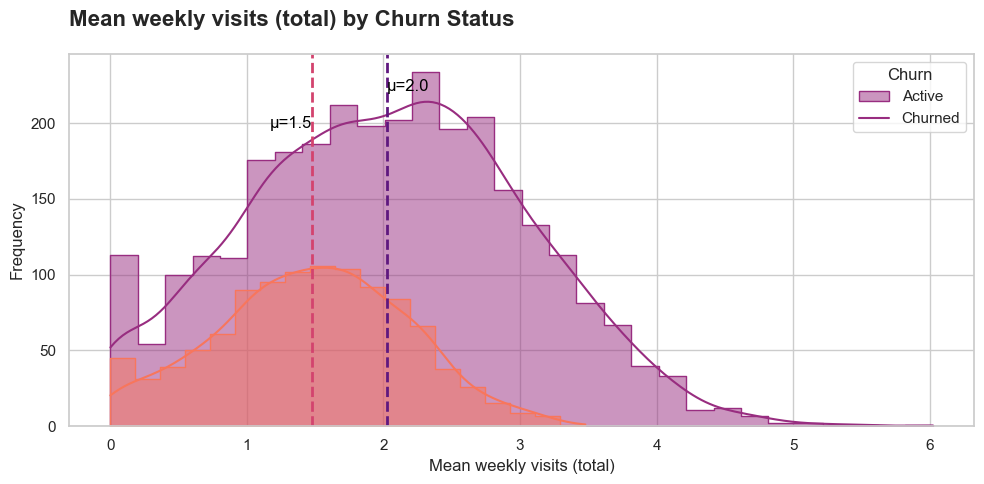

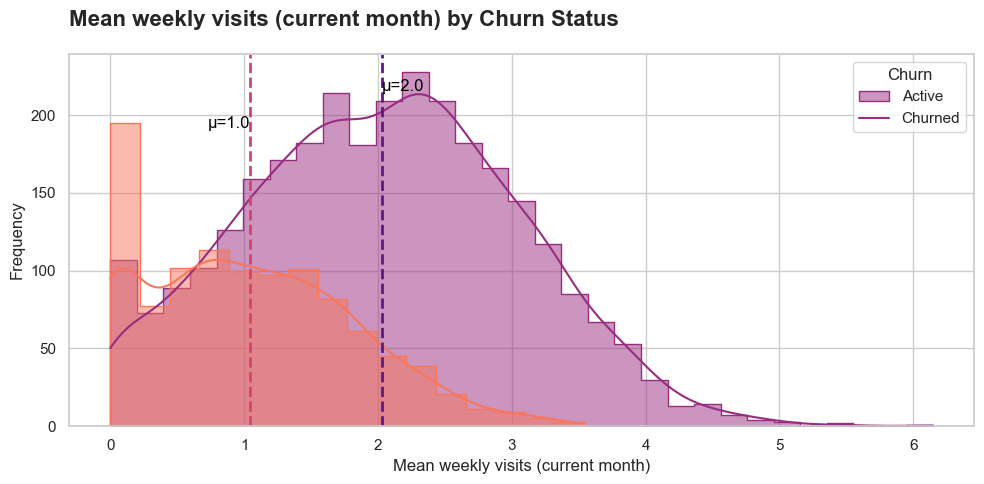

In [16]:
# Color palette ('magma' palette from sns)
color_1 = '#221150'
color_2 = '#5f187f'
color_3 = '#982d80'
color_4 = '#d3436e'
color_5 = '#f8765c'
color_6 = '#febb81'

# Create two separated datgaframes for active and churned users
active_users = df[df['churn'] == 0]
churned_users = df[df['churn'] == 1]

# Create histrograms and bar charts for both groups
# Create a dictionary with the titles for the charts
chart_name = {
    new_columns_names[0] : 'Gender',
    new_columns_names[1] : 'Near Location',
    new_columns_names[2] : 'Partnered',
    new_columns_names[3] : 'Promo-Friends',
    new_columns_names[4] : 'Phone',
    new_columns_names[5] : 'Contract length',
    new_columns_names[6] : 'Group sessions',
    new_columns_names[7] : 'Age',
    new_columns_names[8] : 'Average Aditional spend',
    new_columns_names[9] : 'Months to end of contract',
    new_columns_names[10] : 'Lifetime (months)',
    new_columns_names[11] : 'Mean weekly visits (total)',
    new_columns_names[12] : 'Mean weekly visits (current month)',
    new_columns_names[13] : 'Churn'
}

# Style selection
sns.set_theme(style="whitegrid")

# Iterate over columns to create plots
for col in new_columns_names:
    # Skip the target column
    if col == 'churn':
        continue
    # Set figure size    
    plt.figure(figsize=(10, 5))

    # Check if the column is categorical or numerical
    if df[col].nunique() < 5:
        # Create crosstab for counts and percentages
        counts = pd.crosstab(df[col], df['churn'])
        percentages = pd.crosstab(df[col], df['churn'], normalize='index') * 100

        # Create stacked bar chart
        ax = counts.plot(kind='bar', stacked=True, color=[color_3, color_5], ax=plt.gca())
        plt.title(f'{chart_name[col]} by User Type (Proportional)', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.xlabel(f'{chart_name[col]}')
        plt.ylabel('User Count')
        plt.xticks(rotation=0)
        plt.legend(title='Churn', labels=['Active', 'Churned'], loc='upper right')

        # Add percentage annotations
        i = 0
        for c in counts.columns:
            for j, p in enumerate(ax.patches[i*len(counts):(i+1)*len(counts)]):
                pct = percentages.iloc[j, i]
                if p.get_height() > 0:
                    x = p.get_x() + p.get_width() / 2
                    y = p.get_y() + p.get_height() / 2
                    ax.annotate(f'{pct:.1f}%', (x, y), ha='center', va='center', 
                                color='white', fontweight='bold', fontsize=10)
            i += 1
            
    else:
        # Create histogram with KDE for numerical columns
        sns.histplot(active_users, x=col, kde=True, element="step", color=color_3, label='Active')
        sns.histplot(churned_users, x=col, kde=True, element="step", color=color_5, label='Churned')
        
        mean_active = active_users[col].mean()
        mean_churned = churned_users[col].mean()
        
        # Add mean lines
        plt.axvline(mean_active, color=color_2, linestyle='--', linewidth=2)
        plt.axvline(mean_churned, color=color_4, linestyle='--', linewidth=2)
        plt.text(mean_active, plt.ylim()[1]*0.9, f'μ={mean_active:.1f}', color='black',)
        plt.text(mean_churned, plt.ylim()[1]*0.8, f'μ={mean_churned:.1f}', color='black', ha='right')
        
        # Set titles and labels
        plt.title(f'{chart_name[col]} by Churn Status', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.xlabel(f'{chart_name[col]}')
        plt.ylabel('Frequency')
        plt.legend(title='Churn', labels=['Active', 'Churned'])
    
    plt.tight_layout() # Adjuts layout automatically
    plt.show()

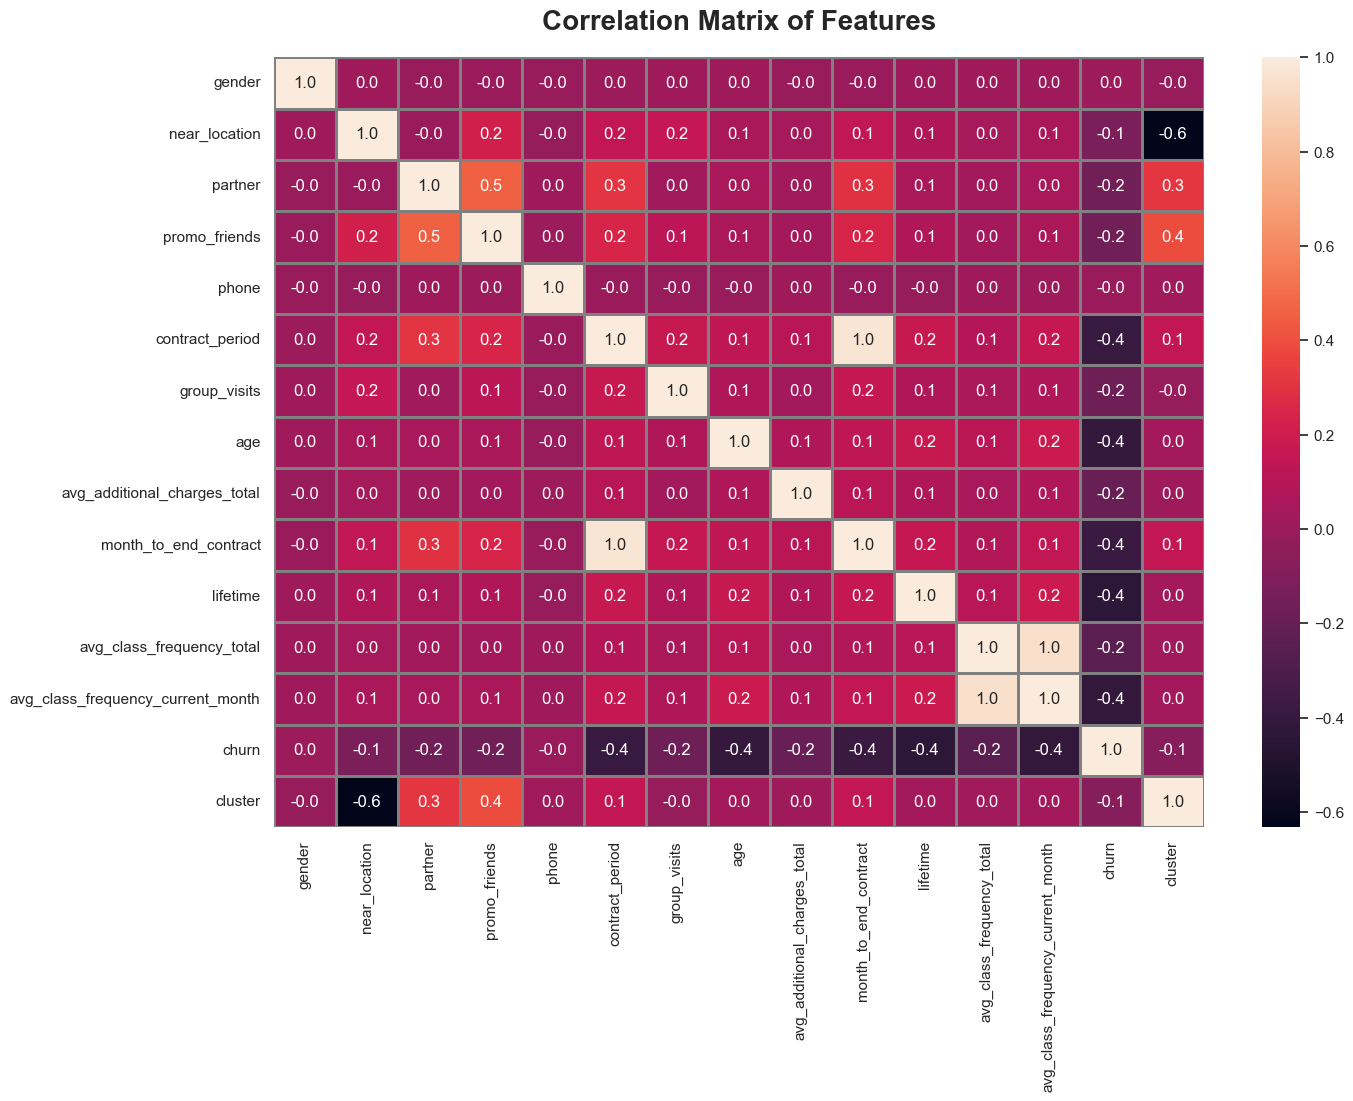

In [17]:
# Correlation matrix and heatmap
# declare variable with correlation matrix
cm = df.corr()

# create heatmap to show matrix
plt.figure(figsize=(15,10))
sns.heatmap(
    cm, 
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='gray'
)

# Set title
plt.title('Correlation Matrix of Features', fontweight='bold', fontsize=20, pad=20)
plt.show()

**INTERMEDIATE CONCLUSIONS**
**Visual Analysis Observations:**

- Gender: Both Gender 0 and Gender 1 show identical percentages of active and churned users.
- Proximity: The churn rate is 15% higher among users who do not live or work near the gym.
- Corporate Partners: There is 14% more churn in the group whose company is not a gym partner.
- Promo-Friend: 15.5% more cancellations occurred in the group that did not sign up through the "Promo-Friends" program.
- Phone Number: Providing a phone number showed no significant difference in churn behavior.
- Contract Duration: Users with 1-month contracts have a 29.8% higher churn rate compared to those with 6-month contracts, and 39.9% higher compared to those with 12-month contracts.
- Group Sessions: Churn is 15.7% higher in the group that does not attend group classes.
- Age: The average age of users who churn is 3 years younger than active users.
- Additional Charges: Users who canceled spent 27.33% less on average on additional services (café, massage, etc.).
- Contract Remaining: The average months remaining until contract expiration for churned users was 1.7 months (3.6 months less than active users).
- Lifetime: Users who churned had an average total subscription time (lifetime) of only 1 month, while active users averaged 4.7 months.
- Attendance Frequency: Average weekly visits (overall) differ by 0.5 visits between churned and active users. However, for the current month, the difference increases to 1 full visit per week.

**Correlation Matrix Insights:**

- High Multicollinearity: The strongest correlations found were between Contract_period and Month_to_end_contract (1.0), and between Avg_class_frequency_total and Avg_class_frequency_current_month (1.0).
- Gender: The 'Gender' feature showed a 0.0 correlation with all other variables.
- Relevant Correlations: Notable positive correlations include Partner and Promo_friends (0.5), as well as Partner with Contract_period (0.3).
- Churn Predictors: Significant negative (inversely proportional) correlations with Churn include Contract_period (-0.4), Age (-0.4), Month_to_end_contract (-0.4), Lifetime (-0.4), and Avg_class_frequency_current_month.

## 3. Churn Prediction Modeling

In [8]:
# create binary classification model for customers
# The target feature is user churn next month

# Dividing features from target variable
X = df.drop('churn', axis=1)
y = df['churn']

# Train two models: Logistic Regression and Random Forest
lr_model = LogisticRegression()
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)

# Define a function to train, predict and evaluate models
def predictive_model(model, X, y):
    # 1. Divide with train_test_split()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # 2. Standardize data
    sc = StandardScaler()
    X_train_sc = sc.fit_transform(X_train)
    X_test_sc = sc.transform(X_test)

    # 3. Train and predict
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    # 4. Evaluate model
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score (y_test, y_pred)
    recall = recall_score (y_test, y_pred)

    # 5. Count predicted churned users
    churned = list(y_pred).count(1)

    # 6. Print results
    model_name = model.__class__.__name__
    print('Model =', model_name)
    print('Prediction:')
    print(f'{churned} Churned users')
    print()
    print('Model metrics:')
    print('Accuracy: {:.2f}'.format(acc))
    print('Precision: {:.2f}'.format(precision))
    print('Recall: {:.2f}'.format(recall))

# Run models and show results
predictive_model(lr_model, X, y)
print()
predictive_model(rf_model, X, y)

Model = LogisticRegression
Prediction:
192 Churned users

Model metrics:
Accuracy: 0.92
Precision: 0.85
Recall: 0.83

Model = RandomForestClassifier
Prediction:
192 Churned users

Model metrics:
Accuracy: 0.92
Precision: 0.84
Recall: 0.81


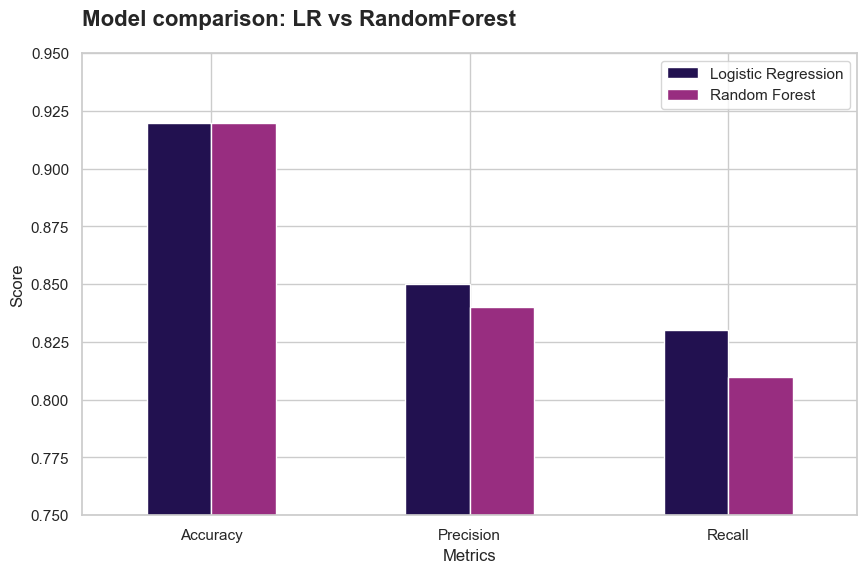

In [9]:
# Display comparison bar chart of model metrics
data = {
    'Metrics': ['Accuracy', 'Precision', 'Recall'],
    'Logistic Regression': [0.92, 0.85, 0.83],
    'Random Forest': [0.92, 0.84, 0.81]
}

df_results = pd.DataFrame(data)
df_results.set_index('Metrics').plot(kind='bar', figsize=(10, 6), rot=0, color=[color_1, color_3])

plt.title('Model comparison: LR vs RandomForest', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.ylabel('Score')
plt.ylim(0.75, 0.95)
plt.legend(loc='upper right')
plt.show()

**INTERMEDIATE CONCLUSIONS:**

**Which model performed better?**

- **Accuracy:** LR (0.92) vs. RF (0.92): Both models achieved identical overall accuracy.

- **Precision:** LR (0.85) vs. RF (0.84): Logistic Regression has slightly fewer false positives. The Random Forest model would flag 1% more customers who aren't actually going to churn compared to LR.

- **Recall (Sensitivity):** LR (0.83) vs. RF (0.81): Logistic Regression captures a higher percentage (2% more) of customers who are truly at risk of leaving.

**The Verdict:** 

Considering the results and the business model of the gym chain, the Logistic Regression model is the best choice for this prediction task.

While both models showed very similar performance, Logistic Regression provides slightly more accurate information regarding the specific customers who require retention efforts. This ensures that the investment in marketing and loyalty strategies is directed more effectively.

The Random Forest model also performed well; however, it carries a higher risk of overspending on "false positives." Investing in unnecessary retention strategies for customers who weren't planning to leave results in "budget leakage." Since the ultimate goal of this study is to maximize gym revenue and efficiency, Random Forest is less suitable for this specific objective.

## 4. Feature Importance

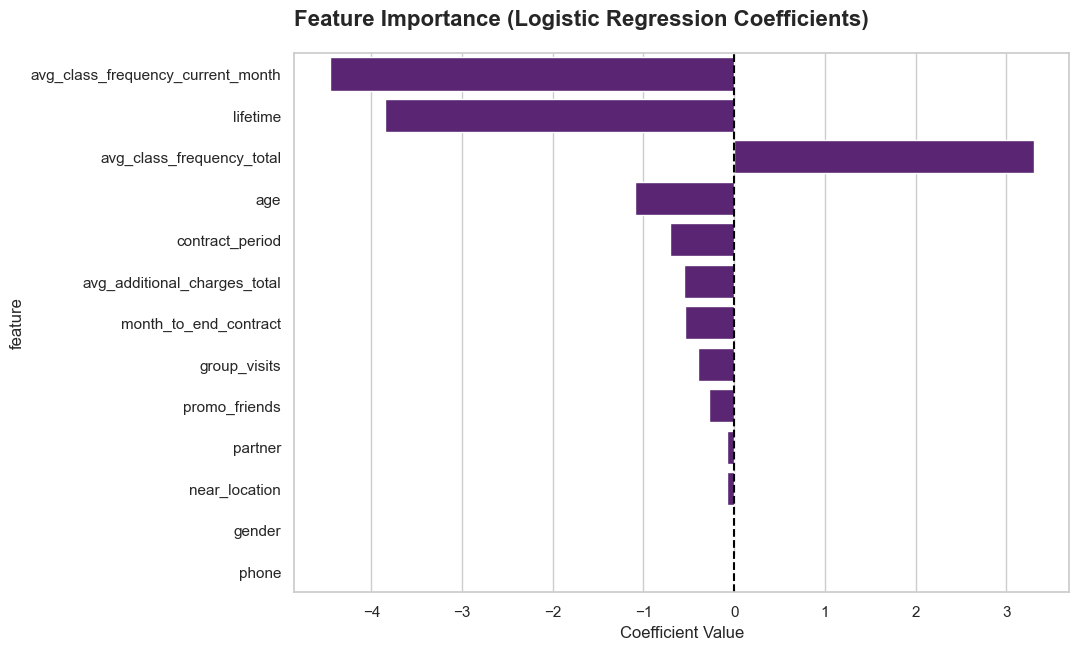

In [10]:
# Extract coefficients
coefficients = lr_model.coef_[0]

# Create a DataFrame to visualize
feature_importance_lr = pd.DataFrame({
    'feature': X.columns,
    'importance': coefficients,
    'abs_importance': np.abs(coefficients) # Absolute value for sorting
}).sort_values(by='abs_importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature', data=feature_importance_lr, color=color_2)
plt.axvline(x=0, color='black', linestyle='--') # Línea en cero para separar lealtad vs churn
plt.title('Feature Importance (Logistic Regression Coefficients)', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.xlabel('Coefficient Value')
plt.show()

**NOTE:**

Multicollinearity was detected among the visit frequency variables. To improve the interpretability of the model's coefficients, we decided to remove one of them. Specifically, we chose to retain 'current month frequency', as it provides the most recent and relevant data regarding customer behavior.

Model = LogisticRegression
Prediction:
207 Churned users

Model metrics:
Accuracy: 0.90
Precision: 0.79
Recall: 0.83


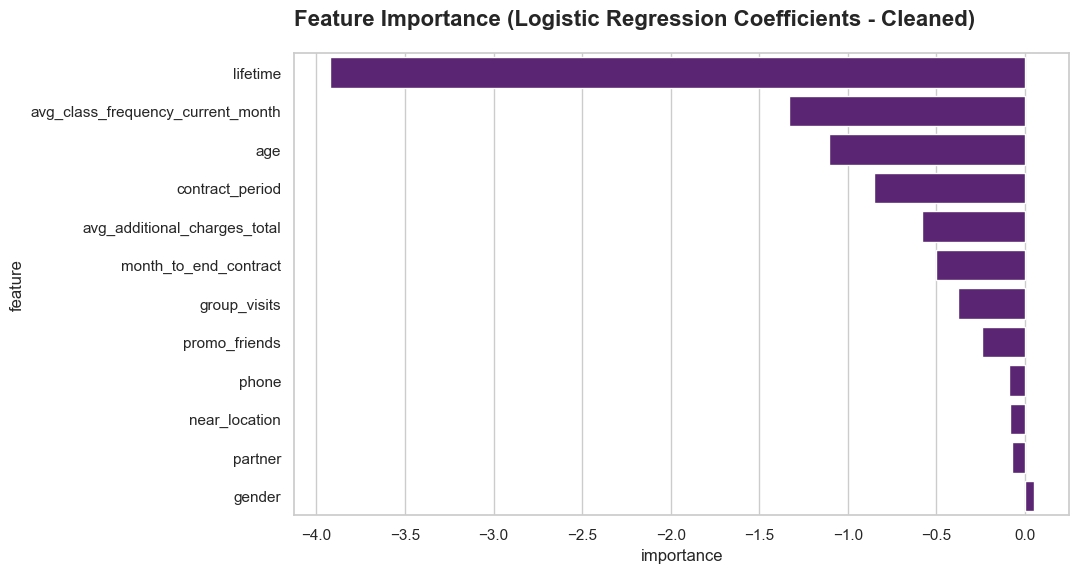

In [11]:
# Deleteing the feature with multicollinearity
X_filtered = X.drop(['avg_class_frequency_total'], axis=1)

# Re-train the model
lr_model_clean = LogisticRegression(random_state=42)

predictive_model(lr_model_clean, X_filtered, y)

# Regraphing the coefficients
coefficients_clean = lr_model_clean.coef_[0]
feature_importance_clean = pd.DataFrame({
    'feature': X_filtered.columns,
    'importance': coefficients_clean
}).sort_values(by='importance')

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_clean, color=color_2)
plt.title('Feature Importance (Logistic Regression Coefficients - Cleaned)', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.show()

**INTERMEDIATE CONCLUSIONS:**

- Model Selection: Although the Random Forest model shows slightly higher precision, Logistic Regression was chosen (after correcting for multicollinearity) because it maintains the highest Recall (0.83). In a retention context, we prioritize identifying the largest possible number of at-risk customers.

- Visit Frequency: The average weekly visits (current month) variable is one of the strongest predictors. This confirms that attendance during the last month serves as the customer's true "thermometer"; a decrease in weekly frequency is an immediate red flag before definitive churn occurs.

- Customer Lifetime: There is a clear inverse relationship between how long a customer has been with the gym and their probability of churn. Customers who survive the critical first few months develop habits that make them much more loyal, suggesting that retention efforts should be concentrated on the user's "first steps."

- Location and Convenience: Physical location remains a determining factor. Customers who live or work nearby have a much lower barrier to exit. This validates that logistical convenience is a pillar of retention for ModelFitness.

- Age and Stability: The model shows that older customers tend to have lower churn rates. This may indicate greater stability in their routines or a more solid commitment to their health goals compared to younger profiles.

- Gender Neutrality: The gender variable shows a coefficient near zero, meaning that churn behavior does not discriminate by gender.

## 5. User Segmentation (Clustering)

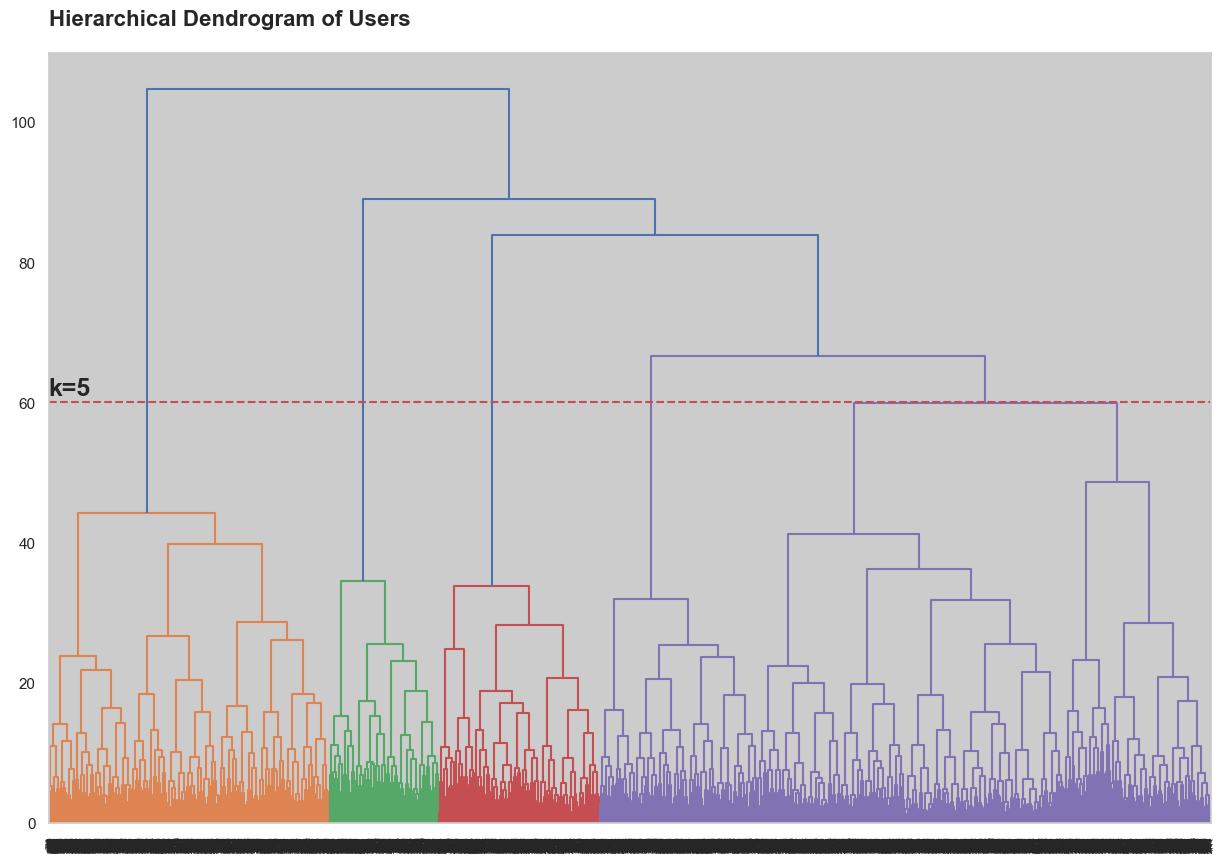

In [18]:
# Deja de lado la columna con datos sobre la cancelación e identifica los clústeres
# Estandariza los datos
sc = StandardScaler()
X_sc = sc.fit_transform(X)

# Utiliza la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada
Z = linkage(X_sc, 'ward')

# trazar un dendrograma
plt.figure(figsize=(15, 10))
dendrogram(Z)
plt.title('Hierarchical Dendrogram of Users', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.axhline(y=60, color='r', linestyle='--')
plt.text(0, 61, 'k=5', fontweight='bold', fontsize=18)
plt.show()


In [13]:
# Entrena el modelo de clustering con el algortimo K-means
# (Deja que el número de clústeres sea n=5)
km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(X_sc)

# Mira los valores medios de característica para los clústeres.
df['cluster'] = labels
df.groupby('cluster').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.486819,1.000000,0.243409,0.007030,0.899824,1.978910,0.326889,28.239016,130.877033,1.896309,2.477153,1.318003,1.083831,0.513181
1,0.592493,0.970509,0.288204,0.123324,0.898123,2.898123,0.482574,30.339142,164.193829,2.654155,5.219839,2.937411,2.944131,0.054960
2,0.499469,0.943677,0.740701,0.489904,0.900106,11.866100,0.551541,29.905420,165.146492,10.852285,4.737513,1.989423,1.980764,0.022317
3,0.483360,1.000000,0.798732,1.000000,0.911252,3.079239,0.445325,29.052298,139.858265,2.873217,3.510301,1.665722,1.547717,0.269414
4,0.496324,0.000000,0.466912,0.077206,0.915441,2.209559,0.215074,28.483456,133.630215,2.073529,2.781250,1.657657,1.466870,0.450368


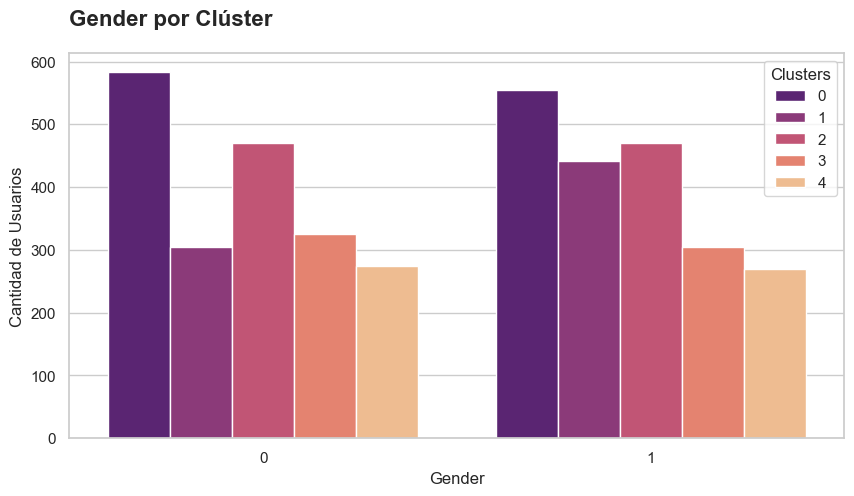

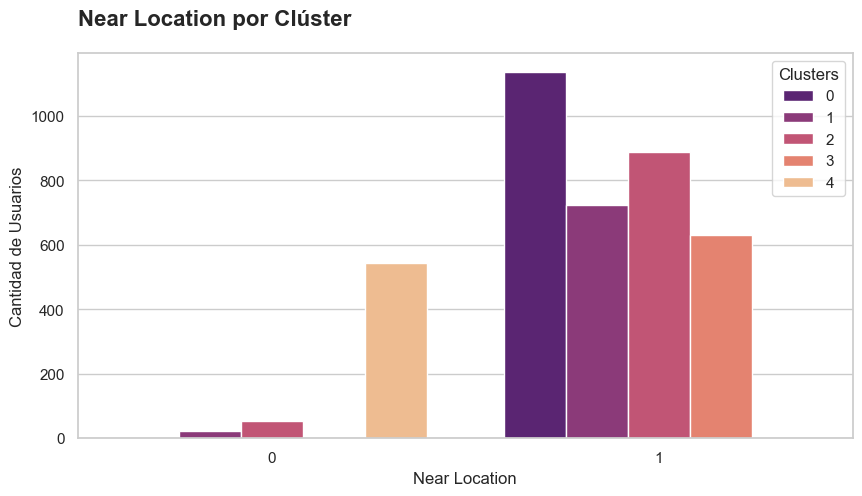

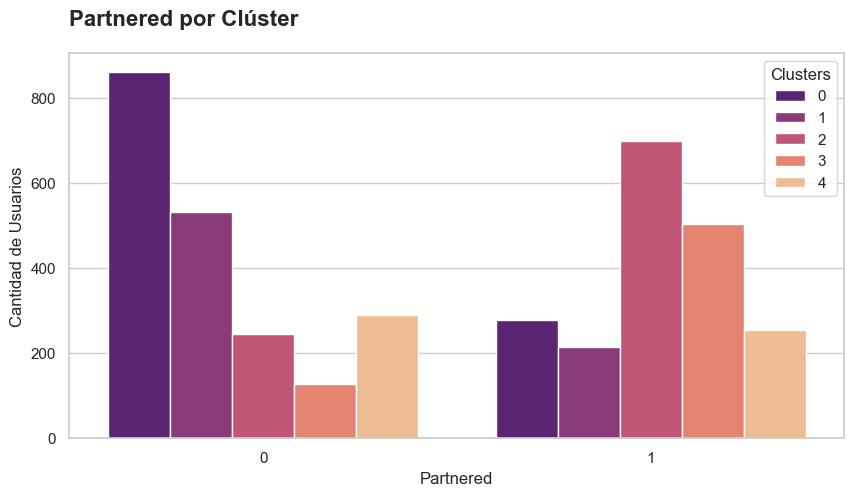

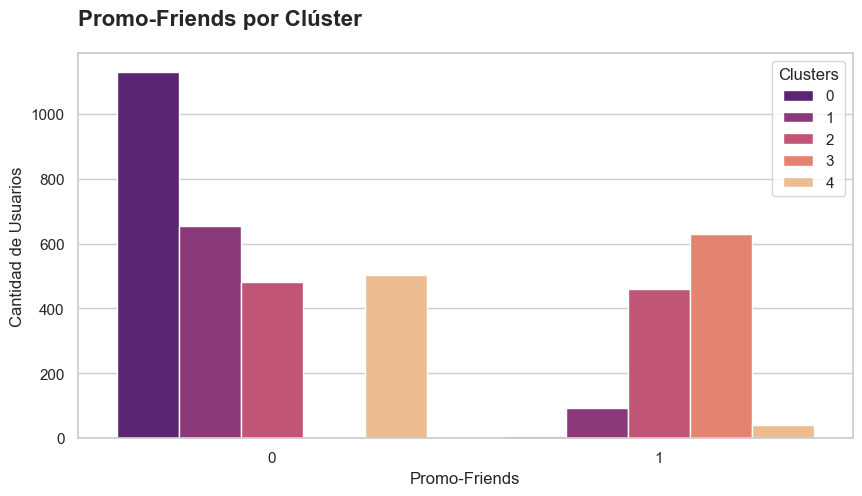

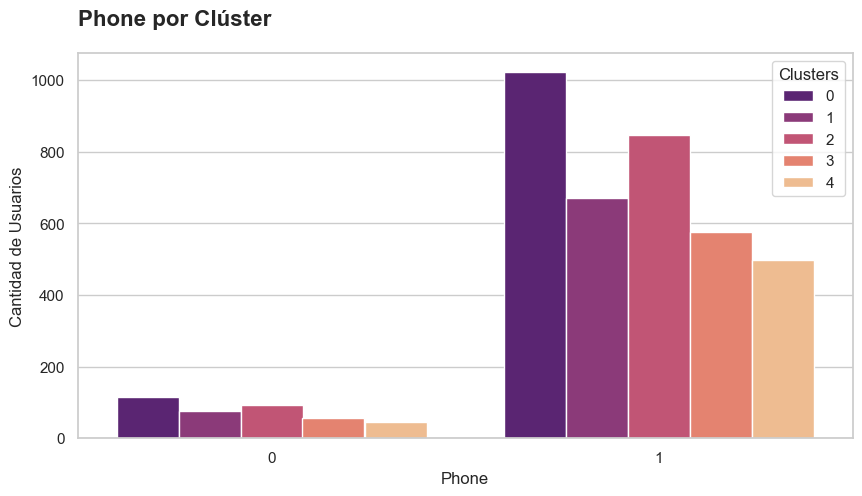

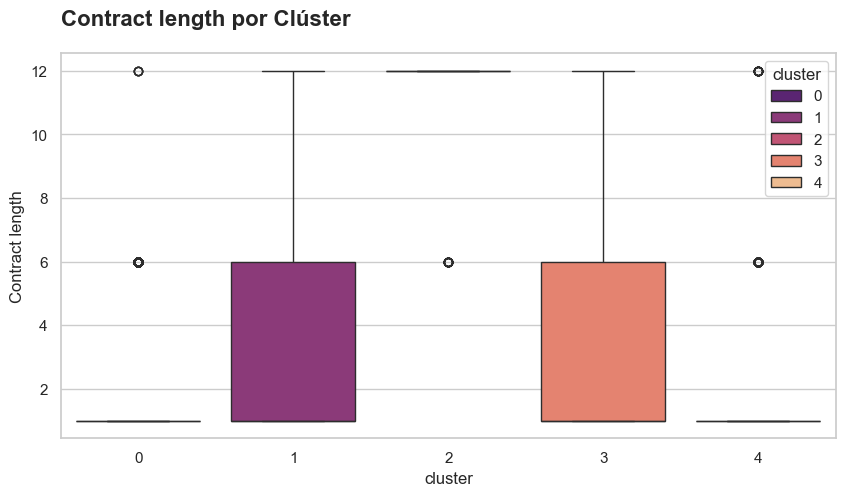

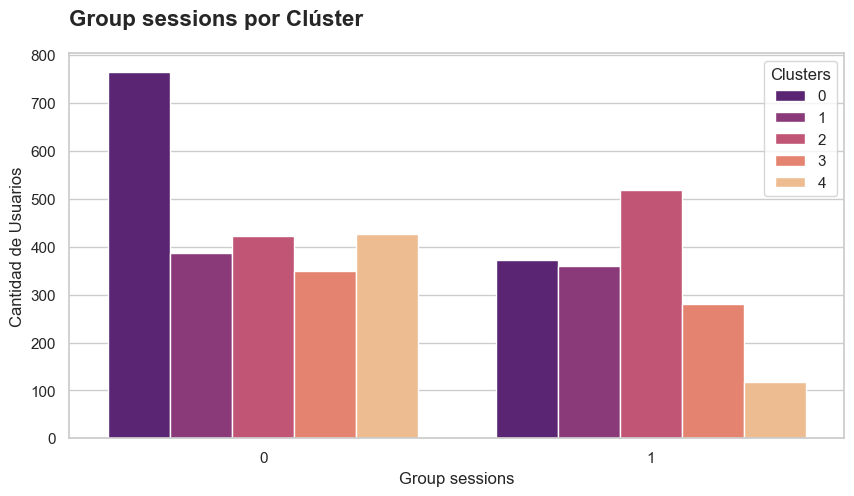

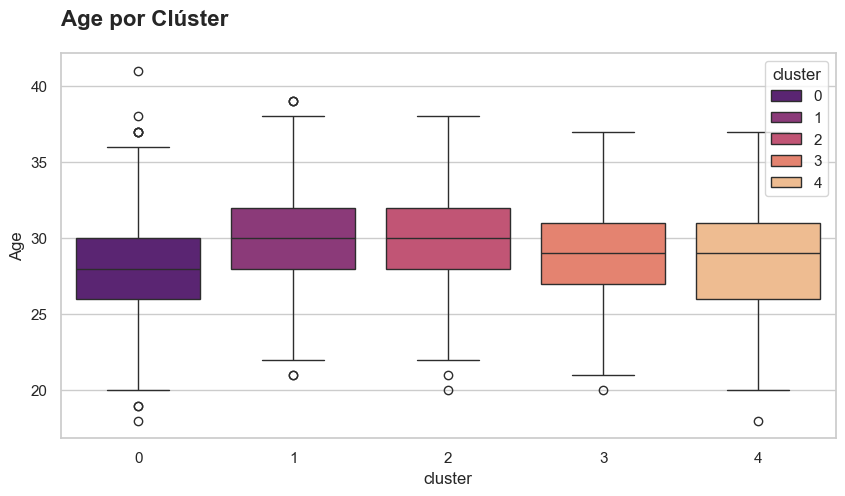

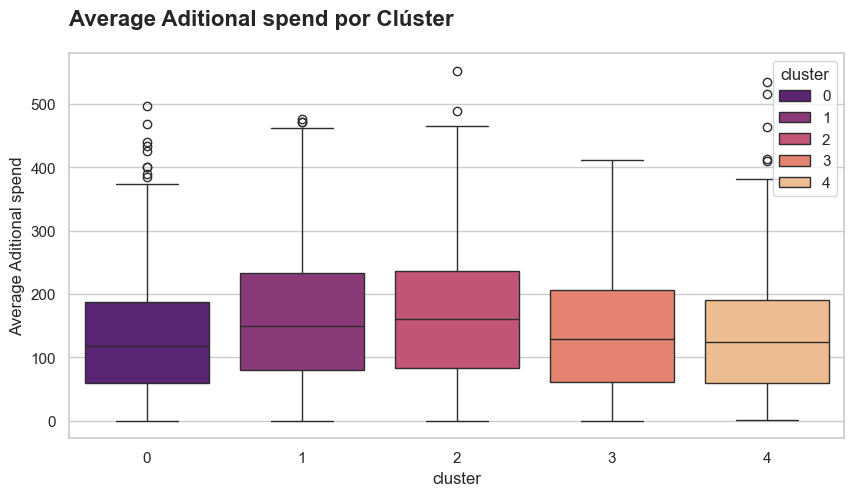

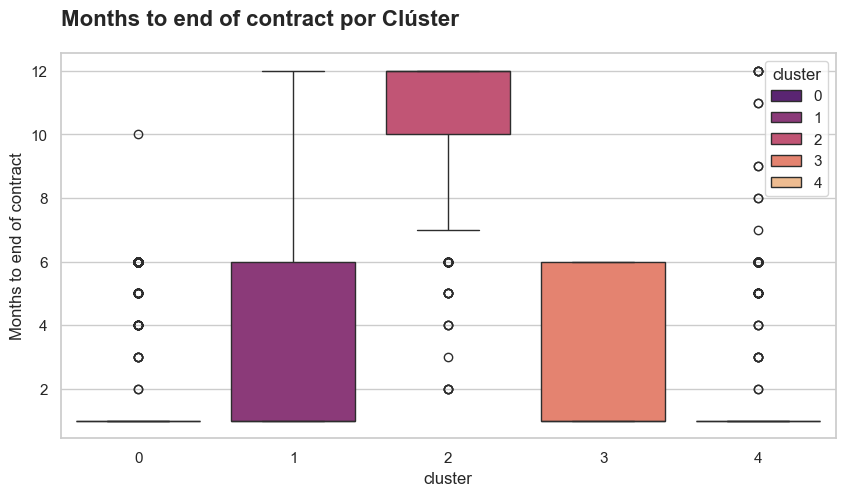

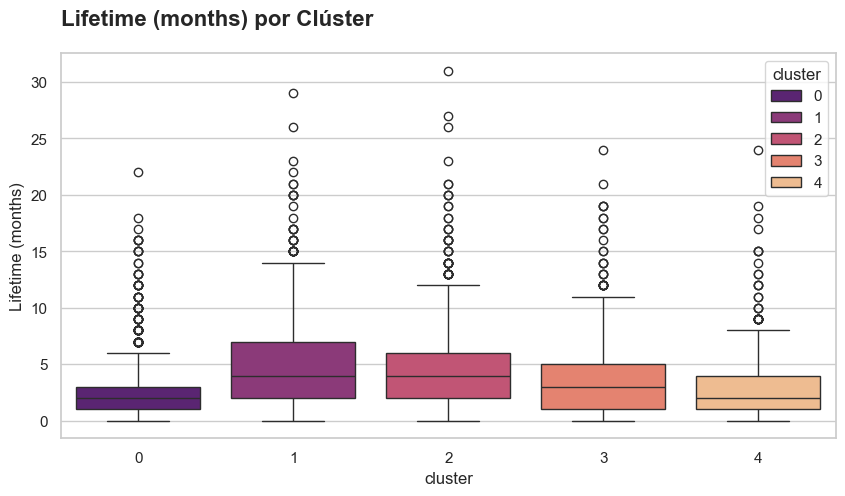

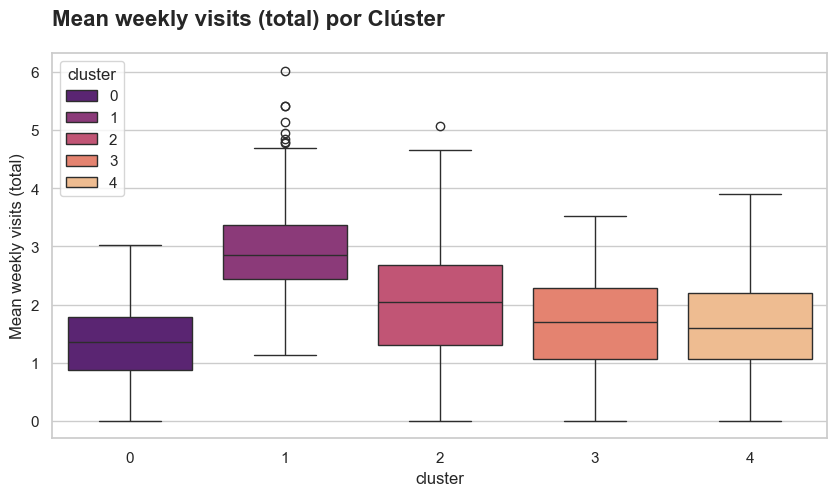

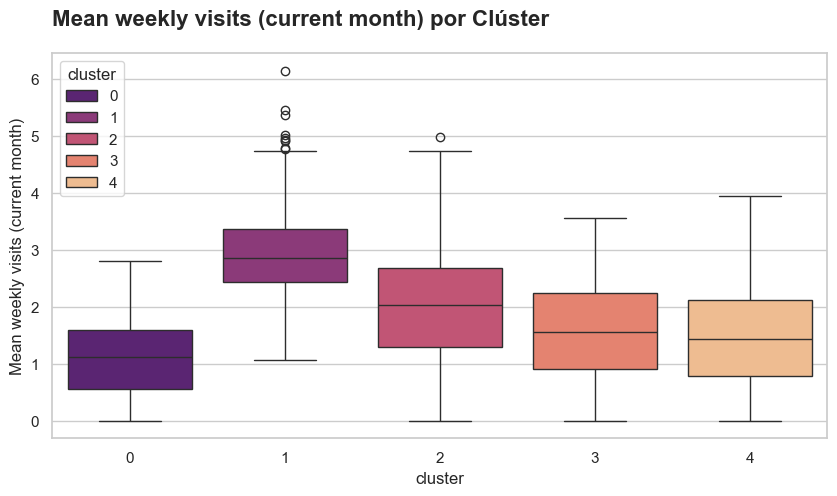

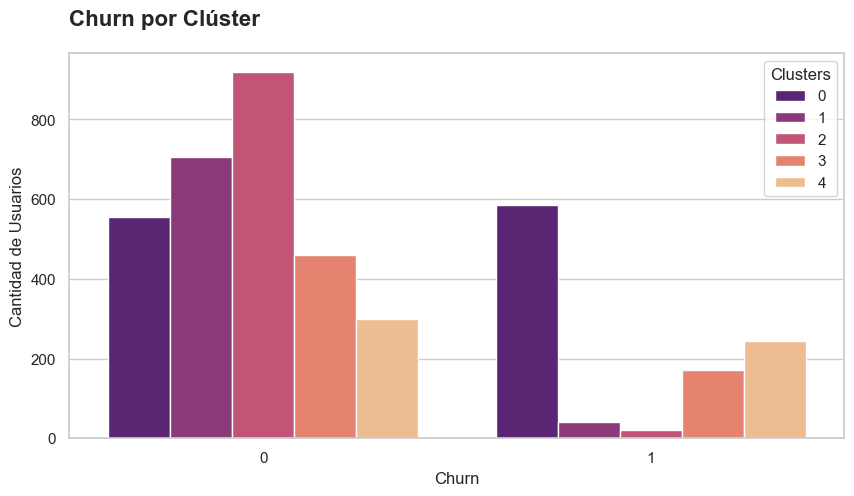

In [14]:
# Traza distribuciones de características para los clústeres
# Excluimos 'cluster' de las características
features = df.drop('cluster', axis=1).columns
colors = [color_2, color_3, color_4, color_5, color_6]

# Iterar sobre las columnas para graficar
for col in features:
    plt.figure(figsize=(10, 5))
    
    # Si la variable es binaria o tiene pocos valores, usamos un gráfico de conteo
    if df[col].nunique() <= 2:
        sns.countplot(x=col, hue='cluster', data=df, palette=colors)
        plt.title(f'{chart_name[col]} por Clúster', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.xlabel(f'{chart_name[col]}')
        plt.ylabel('Cantidad de Usuarios')
        plt.legend(title='Clusters', loc='upper right')
    
    # Si la variable es continua, usamos un boxplot para ver la dispersión
    else:
        sns.boxplot(x='cluster', y=col, data=df, hue='cluster', palette=colors)
        plt.title(f'{chart_name[col]} por Clúster', fontweight='bold', fontsize=16, loc='left', pad=20)
        plt.ylabel(f'{chart_name[col]}')

    plt.show()

Tasa de cancelación por clúster:
cluster
0    0.513181
1    0.054960
2    0.022317
3    0.269414
4    0.450368
Name: churn, dtype: float64



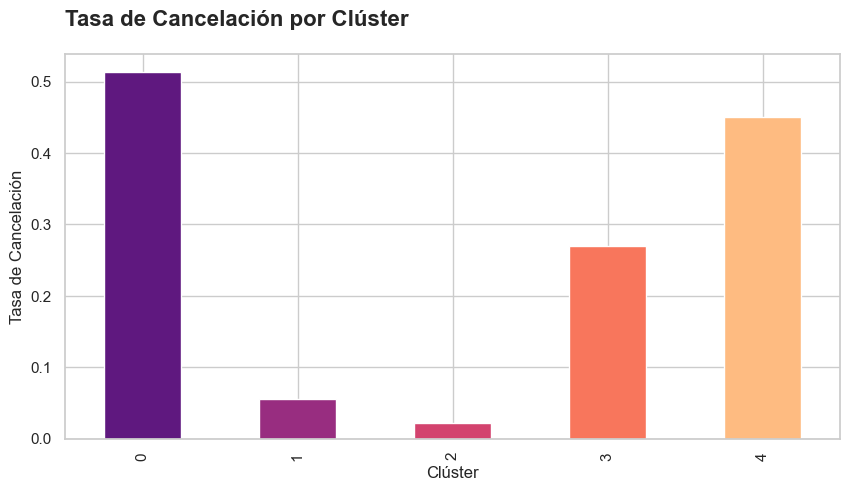

In [15]:
# Calcula la tasa de cancelación para cada clúster (groupby())
# ¿Difieren los grupos?
churn_rate = df.groupby('cluster')['churn'].mean()
print("Tasa de cancelación por clúster:")
print(churn_rate)
print()

# Graficar la tasa de cancelación
plt.figure(figsize=(10, 5))
churn_rate.plot(kind='bar', color=colors)
plt.title('Tasa de Cancelación por Clúster', fontweight='bold', fontsize=16, loc='left', pad=20)
plt.xlabel('Clúster')
plt.ylabel('Tasa de Cancelación')
plt.show()

<b>CONCLUSIONES INTERMEDIAS:</b>

Las características que se detectaron en los Clústers son las siguientes:

<b>Clúster 0 - Perfil Ejecutivo</b>

(Clientes de mayor valor):
- Tienen la tasa de cancelación más baja (2%)
- Segundo grupo con mayor cantidad de visitas promedio.
- Grupo al que le faltan mas meses para finalizar contrato.
- Grupo con altos cargos adicionales.
- Edades más altas.
- Tienen los contratos más largos (12 meses).
- Vienen de parte de una compañía asociada.
- El mayor porcentaje que usó la Promo-Amigos
- Tienen cercanía al gimnasio.

Resumen: Este perfil se distingue por mayor poder adquisitivo, pero que también aprovecha los descuentos. Edad más alta, vienen de una compañia asociada, probablemente es un perfil con mayor estabilidad ecónomica y mayor madurez, el riesgo de perder a estos clientes es el más bajo.

<b>Clúster 1 - Perfil sin Contacto</b>

(Clientes de riesgo medio):
- Visitas menos frecuentes
- Contratos de principalmente entre 1 y 6 meses.
- Edades intermedias.
- Grupo sin telefono de contacto.
- La mayortía tiene cercanía al gimnasio.

Resumen: El riesgo de cancelación de este grupo es moderado (26.75%). Su principal característica es la ausencia de telefono de contacto, en las demas caracteristicas esta a un nivel intermedio del resto de los clústeres.

<b>Clúster 2 - Perfil de mayor Distancia</b>

(Clientes de alto riesto):
- Segundo lugar en menor cantidad de visitas.
- La mayoría esta a un mes de finalizar su contrato.
- Pocos gastos adicionales al mes.
- Entre los grupos mas jóvenes.
- Menor participación en sesiones grupales.
- Principalmente contratos de 1 mes.
- El grupo que menos usa la Promo-Amigos.
- Ninguno cumple con la cercanía al gimnasio.

Resumen: Su riesgo de cancelación es alto (44%). Se caracteriza por no estar cercanos al gimansio, esto podría dificultar más las visitas y por lo tanto el compromiso con el gimnasio. También es de los grupos con contratos de menor compromiso (1 mes).

<b>Clúster 3 - Perfil Jóven/Inexperto</b>
(Clientes críticos): 
- La tasa de cancelación más alta (51.42%)
- La menor cantidad de visitas
- El grupo de menor cantidad de meses inscrito.
- Menor cantidad de meses para finalizar.
- Menor cantidad de cargos adicionales.
- El grupo más jóven.
- La menor asistencia a sesiones grupales.
- Contratos principalmente de 1 mes.
- El grupo que menos uso hace de la Promo-Amigos, o descuentos de compañias asociadas.
- Todos tienen cercanía al gimnasio.

Resumen: Se distinguen por ser el grupo más jóven, que menos gasta, pero también que menos utiliza descuentos. Se comprometen menos a contratos largos y no mostraron disciplina en la asistencia. Probablemente sea un grupo más inmaduro o inexperto en gimnasios, pero que por la cercanía hicieron el intento de inscribirse.

<b>Clúster 4 - Perfil Atlético</b>

(Clientes riesgo bajo):
- Tasa de cancelación muy baja (6%).
- Tienen la mayor cantidad de visitas por semana.
- Tienen entre 1 y 5 meses para finalizar su contrato.
- Entre los grupos con mayores gastos adicionales.
- Entre los grupos de mayor edad.
- Contratos de entre 1 y 6 meses.
- La mayoría tienen cercanía al gimnasio.

Resumen: Perfil con mayor experiencia y disciplina en el gimnasio. Probablemente no dejarán el gimnasio porque estan acostumbrados a entrenar y factores como la cercanía y servicios adicionales adquiridos los mantienen activos.

## 6. Conclusiones y Recomendaciones

Para maximizar los ingresos de la cadena de gimnasios ModelFitnes, se proponen 3 estrategias diferenciadas por el nivel de riesgo de cada Clúster.

<b>1. Estrategia de Retención Activa (Para Clúster 2 y 3):</b>
- Como el Clúster 1 es el más inexperto, una campaña de 'Coaching' durante el primer mes puede lograr atravesar la dificl barrera del primer mes, ayudar a los nuevos usuarios a generar compromiso y habito por el ejercicio.
-  Para el Clúster 2, que es el que tiene problemas por la lejanía se podrían proponer estrategias que ataquen directamente el problema de la movilidad como ofrecer promociones por hacer 'Carpool' o ofrecer algun plan de entrenamiento remoto o híbrido.
-  Para ambos grupos se debe de buscar una estrategia que convenga ambas partes para que sus contratos sean de más de un mes, ya que en los otros Clústers con menor tasa de cancelación es una característica que comparten.

<b>2. Estrategia de Actualización (Para Clúster 1):</b>
- Campaña para que registren sus números telefónicos, ya que sin datos de contacto no es posible hacer marketing de retención.
- La estrategía con este Clúster debe buscar que los usuarios asistan con mayor frecuencia a entrenar, ya que esta característica se relaciona con mayor fidelidad.

<b>3. Estrategia de Fidelización (Para Clúster 0 y 4):</b>
- El objetivo con estos usuarios es mantenerlos motivados. Como estos dos grupos muestran la mayor cantidad de gastos adicionales, se les pueden enviar ofertas exclusivas para servicios adicionales premium. Como es un perfil mas adulto, y con tendencia a invertir en servicios de gimnasio, son un grupo mas propenso a aceptar ofertas de servicios adicionales que les resulten atractivos.
- Como el Clúster 0 ya usa la Promo-Amigos, es posible que a traves de este grupo se puedan atraer mas clientes del mismo perfil, si se les ofrece alguna promoción por invitar más usuarios.